In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 2000
n_features = 1000
n_true_factors = 200

# 200 true factors, combined randomly to create 1000 observed features
true_factors = rng.normal(0, 1, size=(n_samples, n_true_factors))
mixing_weights = rng.normal(0, 1, size=(n_true_factors, n_features))
X = true_factors @ mixing_weights + rng.normal(0, 0.5, size=(n_samples, n_features))

In [3]:
# the target depends on the same true factors (plus noise) hence PCA won't throw away the signal, just the redundant noise
true_coefficients = rng.normal(0, 1, size=(n_true_factors,))
y = true_factors @ true_coefficients + rng.normal(0, 5, size=(n_samples,))

print(f"X shape: {X.shape} (1000 columns, but only {n_true_factors} are truly independent)")

X shape: (2000, 1000) (1000 columns, but only 200 are truly independent)


# Train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression().fit(X_train_scaled, y_train)
baseline_r2 = r2_score(y_test, baseline_model.predict(X_test_scaled))

print(f"Linear regression on all {X.shape[1]} raw features: test R^2 = {baseline_r2:.3f}")

Linear regression on all 1000 raw features: test R^2 = 0.630


# Applying PCA 

In [5]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance_ratio = np.cumsum(pca_full.explained_variance_ratio_)

for n in [50, 100, 150, 200, 250, 500]:
    print(f"First {n:4d} components explain {cumulative_variance_ratio[n-1]:.1%} of the variance")

First   50 components explain 45.4% of the variance
First  100 components explain 73.2% of the variance
First  150 components explain 90.4% of the variance
First  200 components explain 99.9% of the variance
First  250 components explain 99.9% of the variance
First  500 components explain 100.0% of the variance


*What to notice* : variance explained jumps very quickly up to ~200 components, then abrely moves at all afterward (250 & 300  add almost nothing extra). That flattening-out is exactly the "elbow" we're looking for, 

# Scree plot

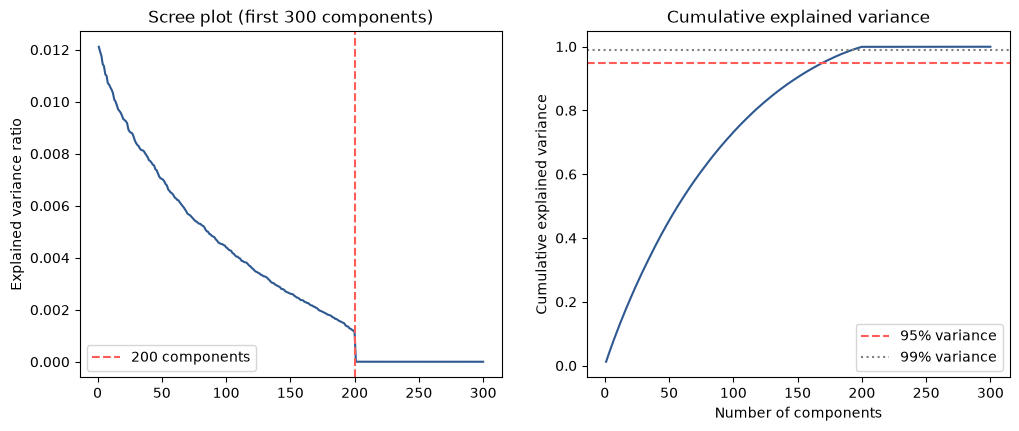

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    range(1, 301),
    pca_full.explained_variance_ratio_[:300],
    color="#2E5890"
)
axes[0].axvline(
    200,
    color="#FF5C57",
    linestyle="--",
    label="200 components"
)
axes[0].set_ylabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (first 300 components)")
axes[0].legend()

axes[1].plot(
    range(1, 301),
    cumulative_variance_ratio[:300],
    color="#2E5890"
)
axes[1].axhline(
    0.95,
    color="#FF5C57",
    linestyle="--",
    label="95% variance"
)
axes[1].axhline(
    0.99,
    color="gray",
    linestyle=":",
    label="99% variance"
)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()